# 🧠 NOTEBOOK 2 — Model Training
## MentalBERT + LIWC + Attention Fusion + BiLSTM

---
### 📌 What this notebook does:
| Step | Task |
|------|------|
| 1 | Install + fix all version conflicts |
| 2 | HuggingFace login (for MentalBERT) |
| 3 | Import libraries |
| 4 | Load processed_data.pkl |
| 5 | Load MentalBERT / BERT-base tokenizer |
| 6 | Dataset class + DataLoaders |
| 7 | Full model architecture |
| 8 | Training loop (5 epochs) |
| 9 | Training curves |
| 10 | Test evaluation |
| 11 | Save results for NB3 |

### ⚙️ Kaggle Settings:
- GPU T4 x2 → **ON**
- Internet   → **ON**
- Persistence → **Variables and Files**
- Upload `processed_data.pkl` → Input section

## STEP 1 — Install + Fix Version Conflicts

In [1]:
import subprocess

print("Fixing huggingface version conflicts...")

subprocess.run(["pip","uninstall","-y",
    "transformers","huggingface-hub",
    "tokenizers","accelerate"], capture_output=True)

cmds = [
    ["pip","install","huggingface-hub==0.20.3","-q"],
    ["pip","install","tokenizers==0.14.1","-q"],
    ["pip","install","transformers==4.35.0","-q"],
    ["pip","install","accelerate==0.24.1","-q"],
]
for cmd in cmds:
    result = subprocess.run(cmd, capture_output=True, text=True)
    pkg = cmd[2]
    if result.returncode == 0:
        print(f"  ✅ {pkg}")
    else:
        print(f"  ⚠️ {pkg}: {result.stderr[-100:]}")

print()
print("✅ All packages installed!")
print()
print("⚠️ IMPORTANT: Restart kernel now!")
print("   Menu → Run → Restart & Clear Outputs")
print("   Then run from STEP 2 onwards")

Fixing huggingface version conflicts...
  ✅ huggingface-hub==0.20.3
  ✅ tokenizers==0.14.1
  ✅ transformers==4.35.0
  ✅ accelerate==0.24.1

✅ All packages installed!

⚠️ IMPORTANT: Restart kernel now!
   Menu → Run → Restart & Clear Outputs
   Then run from STEP 2 onwards


## STEP 2 — HuggingFace Login (For MentalBERT)

In [ ]:
# ════════════════════════════════════════════════
# 🔑 PASTE YOUR HUGGINGFACE TOKEN HERE
# Get it from: huggingface.co/settings/tokens
# Role: Read
# ════════════════════════════════════════════════

HUGGINGFACEHUB_API_TOKEN="hf_xxxxx"
import os
from huggingface_hub import login

# ✅ FIX 4: Safe defaults before any login attempt
USE_MENTAL_BERT = False

if HF_TOKEN != "hf_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" and len(HF_TOKEN) > 10:
    try:
        login(token=HF_TOKEN, add_to_git_credential=False)
        os.environ["HF_TOKEN"] = HF_TOKEN
        USE_MENTAL_BERT = True
        print("✅ HuggingFace login successful!")
        print("   MentalBERT will be used")
    except Exception as e:
        print(f"⚠️ Login failed: {e}")
        HF_TOKEN = None          # ✅ FIX 4: reset to None on failure
        USE_MENTAL_BERT = False
else:
    print("⚠️ No HF token provided")
    print("   Will use BERT-base-uncased (fallback)")
    HF_TOKEN = None              # ✅ FIX 4: ensure HF_TOKEN always defined
    USE_MENTAL_BERT = False

print()
print(f"Model to use: {'MentalBERT' if USE_MENTAL_BERT else 'BERT-base'}")

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful
✅ HuggingFace login successful!
   MentalBERT will be used

Model to use: MentalBERT


## STEP 3 — Import All Libraries

In [3]:
import numpy as np
import pandas as pd
import os, re, warnings, pickle
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, cohen_kappa_score,
    precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device  : {device}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ CUDA    : {torch.cuda.is_available()}")

✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ CUDA    : True


## STEP 4 — Load processed_data.pkl

In [4]:
pkl_path = None
print("Searching for processed_data.pkl...")
for root, dirs, files in os.walk('/kaggle/input'):
    for fname in files:
        if 'processed_data' in fname and fname.endswith('.pkl'):
            pkl_path = os.path.join(root, fname)
            print(f"✅ Found: {pkl_path}")
            break
    if pkl_path:
        break

if pkl_path is None:
    print()
    print("❌ processed_data.pkl NOT FOUND!")
    print("   → Add it via the Input section on the right sidebar")
    raise FileNotFoundError("processed_data.pkl missing")

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

X_train  = data['X_train'];  X_val  = data['X_val'];  X_test  = data['X_test']
y_train  = data['y_train'];  y_val  = data['y_val'];  y_test  = data['y_test']
lw_train = data['lw_train']; lw_val = data['lw_val']; lw_test = data['lw_test']
LIWC_NAMES = data['LIWC_NAMES']
N_LIWC   = int(lw_train.shape[1])

print(f"✅ Loaded!")
print(f"   Train : {len(X_train):,}")
print(f"   Val   : {len(X_val):,}")
print(f"   Test  : {len(X_test):,}")
print(f"   LIWC  : {N_LIWC} features")

Searching for processed_data.pkl...
✅ Found: /kaggle/input/datasets/komal01kumari01/processed-data/processed_data.pkl
✅ Loaded!
   Train : 17,201
   Val   : 3,686
   Test  : 3,687
   LIWC  : 12 features


## STEP 5 — Load MentalBERT (Auto-Fallback to BERT-base)

In [5]:
MENTAL_MODEL   = 'mental/mental-bert-base-uncased'
FALLBACK_MODEL = 'bert-base-uncased'

MODEL_TO_TRY = MENTAL_MODEL if USE_MENTAL_BERT else FALLBACK_MODEL

print(f"Loading: {MODEL_TO_TRY}")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_TO_TRY,
        token=HF_TOKEN if USE_MENTAL_BERT else None)
    MODEL_NAME = MODEL_TO_TRY
    print(f"✅ Tokenizer loaded: {MODEL_NAME}")
except Exception as e:
    print(f"⚠️ Failed ({str(e)[:80]})")
    print(f"   Falling back to: {FALLBACK_MODEL}")
    tokenizer  = AutoTokenizer.from_pretrained(FALLBACK_MODEL)
    MODEL_NAME = FALLBACK_MODEL
    USE_MENTAL_BERT = False      # ✅ FIX 4: keep flags consistent
    HF_TOKEN        = None
    print(f"✅ BERT-base tokenizer loaded (fallback)")

MAX_LEN    = 128
BATCH_SIZE = 16
print(f"   MAX_LEN : {MAX_LEN}")
print(f"   BATCH   : {BATCH_SIZE}")

Loading: mental/mental-bert-base-uncased


✅ Tokenizer loaded: mental/mental-bert-base-uncased
   MAX_LEN : 128
   BATCH   : 16


## STEP 6 — Dataset Class + DataLoaders

In [6]:
class DepDataset(Dataset):
    def __init__(self, texts, labels, liwc, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.liwc      = liwc
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'liwc'           : torch.tensor(self.liwc[idx],   dtype=torch.float),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# num_workers=0 — safe for Kaggle (avoids fork errors)
train_dl = DataLoader(
    DepDataset(X_train, y_train, lw_train, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl = DataLoader(
    DepDataset(X_val, y_val, lw_val, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(
    DepDataset(X_test, y_test, lw_test, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ DataLoaders ready!")
print(f"   Train: {len(train_dl)} batches")
print(f"   Val  : {len(val_dl)} batches")
print(f"   Test : {len(test_dl)} batches")

✅ DataLoaders ready!
   Train: 1076 batches
   Val  : 231 batches
   Test : 231 batches


## STEP 7 — Full Model Architecture

In [7]:
class DepressionDetector(nn.Module):
    """
    Architecture:
    Text → BERT[768] → Proj[256] ──┐
                                    ├→ Attention Gate → BiLSTM → FC → Out
    LIWC[N] ───→ Proj[256] ─────────┘
    """
    def __init__(self, model_name, liwc_dim=12,
                 proj_dim=256, lstm_hidden=128,
                 lstm_layers=2, n_classes=2, dropout=0.3):
        super().__init__()

        # ── Backbone ──────────────────────────────────────────────────────────
        try:
            self.backbone = AutoModel.from_pretrained(
                model_name,
                token=HF_TOKEN if (USE_MENTAL_BERT and HF_TOKEN) else None)
            print(f"  ✅ Backbone loaded: {model_name}")
        except Exception as e:
            print(f"  ⚠️ Backbone failed, using bert-base: {str(e)[:60]}")
            self.backbone = AutoModel.from_pretrained('bert-base-uncased')

        # Freeze bottom 8 BERT layers, fine-tune top 4
        if hasattr(self.backbone, 'encoder'):
            for i, layer in enumerate(self.backbone.encoder.layer):
                for p in layer.parameters():
                    p.requires_grad = (i >= 8)

        # ── Projections ───────────────────────────────────────────────────────
        # BERT 768 → proj_dim
        self.bert_proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout))

        # ✅ FIX 5: comment now uses liwc_dim variable, not hardcoded 12
        # LIWC liwc_dim → proj_dim
        self.liwc_proj = nn.Sequential(
            nn.Linear(liwc_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout))

        # ── Attention Gate ────────────────────────────────────────────────────
        self.attn_gate = nn.Sequential(
            nn.Linear(proj_dim * 2, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.Softmax(dim=-1))

        # ── BiLSTM ────────────────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0)

        # ── Classifier ────────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes))

    def forward(self, input_ids, attn_mask, liwc):
        out    = self.backbone(input_ids=input_ids,
                               attention_mask=attn_mask)
        cls    = out.last_hidden_state[:, 0, :]          # (B, 768)
        b_feat = self.bert_proj(cls)                      # (B, proj_dim)
        l_feat = self.liwc_proj(liwc)                     # (B, proj_dim)

        cat    = torch.cat([b_feat, l_feat], dim=-1)      # (B, proj_dim*2)
        wts    = self.attn_gate(cat)                      # (B, 2)
        fused  = wts[:, 0:1] * b_feat + wts[:, 1:2] * l_feat  # (B, proj_dim)

        _, (hn, _) = self.bilstm(fused.unsqueeze(1))
        temporal   = torch.cat([hn[-2], hn[-1]], dim=-1)  # (B, lstm_hidden*2)

        logits = self.classifier(temporal)                 # (B, n_classes)
        return logits, wts


# ── Build ──────────────────────────────────────────────────────────────────────
print(f"Building model with: {MODEL_NAME}")
model = DepressionDetector(
    model_name=MODEL_NAME, liwc_dim=N_LIWC).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready!")
print(f"   Total params    : {total:,}")
print(f"   Trainable params: {trainable:,}")
print(f"   Frozen params   : {total - trainable:,}")

Building model with: mental/mental-bert-base-uncased


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ✅ Backbone loaded: mental/mental-bert-base-uncased
✅ Model ready!
   Total params    : 110,595,460
   Trainable params: 53,892,484
   Frozen params   : 56,702,976


## STEP 8 — Training

In [8]:
EPOCHS = 5
LR     = 2e-5

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS)


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    """
    Run one full epoch.
    Returns: (avg_loss, accuracy, f1, preds, labels, probs, attn_weights)
    """
    model.train() if train else model.eval()
    tot_loss = 0.0
    all_preds, all_labels = [], []
    all_probs, all_attn   = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            liwc = batch['liwc'].to(device)
            lbl  = batch['label'].to(device)

            logits, attn_w = model(ids, mask, liwc)
            loss = criterion(logits, lbl)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tot_loss += loss.item()
            preds = logits.argmax(dim=1)
            probs = torch.softmax(logits, dim=1)[:, 1]

            # ✅ FIX 1: .detach() required before .numpy() during training
            #    because enable_grad() keeps requires_grad=True on outputs
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(lbl.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_attn.extend(attn_w.detach().cpu().numpy())

    avg_loss = tot_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1, all_preds, all_labels, all_probs, all_attn


print("✅ Training setup ready")

✅ Training setup ready


In [9]:
history = {
    'tl': [], 'vl': [],
    'ta': [], 'va': [],
    'tf1': [], 'vf1': []
}
best_f1      = 0.0
best_weights = None

print(f"🚀 Training: {MODEL_NAME}")
print(f"   Epochs:{EPOCHS} | LR:{LR} | Batch:{BATCH_SIZE}")
print()

hdr = (f"{'Ep':>3} | {'T-Loss':>8} {'T-Acc':>7} {'T-F1':>7}"
       f" | {'V-Loss':>8} {'V-Acc':>7} {'V-F1':>7}")
print(hdr)
print('─' * len(hdr))

for ep in range(1, EPOCHS + 1):
    tl, ta, tf1, *_ = run_epoch(
        model, train_dl, optimizer, criterion, device, train=True)

    vl, va, vf1, vp, vlt, vpr, _ = run_epoch(
        model, val_dl, None, criterion, device, train=False)

    history['tl'].append(tl);  history['vl'].append(vl)
    history['ta'].append(ta);  history['va'].append(va)
    history['tf1'].append(tf1); history['vf1'].append(vf1)

    tag = ''
    # ✅ FIX 3: save best weights BEFORE stepping scheduler
    if vf1 > best_f1:
        best_f1      = vf1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        tag = ' ← BEST ✅'

    # ✅ FIX 3: scheduler steps AFTER best-weight check
    scheduler.step()

    print(f"{ep:>3} | {tl:>8.4f} {ta:>7.4f} {tf1:>7.4f}"
          f" | {vl:>8.4f} {va:>7.4f} {vf1:>7.4f}{tag}")

# ✅ FIX 2: guard against None best_weights (safety check)
if best_weights is not None:
    model.load_state_dict(best_weights)
    torch.save(best_weights, '/kaggle/working/mentalbert_best.pt')
    print(f"\n✅ Done! Best Val F1 = {best_f1:.4f}")
    print(f"✅ Saved → mentalbert_best.pt")
else:
    print("\n⚠️ No best weights saved — using last epoch weights")
    torch.save(model.state_dict(), '/kaggle/working/mentalbert_best.pt')
    print(f"✅ Saved last epoch → mentalbert_best.pt")

🚀 Training: mental/mental-bert-base-uncased
   Epochs:5 | LR:2e-05 | Batch:16

 Ep |   T-Loss   T-Acc    T-F1 |   V-Loss   V-Acc    V-F1
─────────────────────────────────────────────────────────
  1 |   0.5827  0.7128  0.7020 |   0.4867  0.7566  0.7562 ← BEST ✅
  2 |   0.4192  0.8068  0.8066 |   0.4173  0.7922  0.7916 ← BEST ✅
  3 |   0.3233  0.8623  0.8623 |   0.4171  0.8098  0.8096 ← BEST ✅
  4 |   0.2582  0.8957  0.8957 |   0.4872  0.8144  0.8142 ← BEST ✅
  5 |   0.2182  0.9183  0.9183 |   0.5664  0.8142  0.8142

✅ Done! Best Val F1 = 0.8142
✅ Saved → mentalbert_best.pt


## STEP 9 — Training Curves

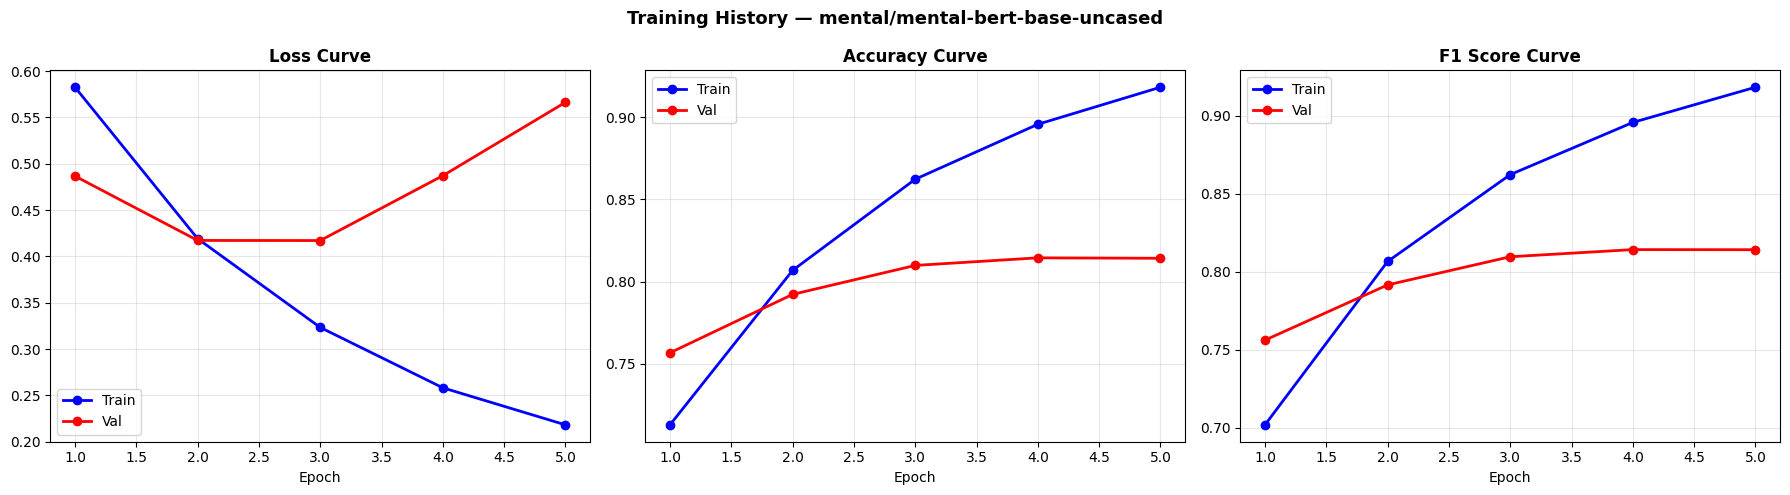

✅ Saved → training_curves.png


In [10]:
ep_r = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Training History — {MODEL_NAME}',
             fontsize=13, fontweight='bold')

pairs  = [
    (history['tl'], history['vl']),
    (history['ta'], history['va']),
    (history['tf1'], history['vf1']),
]
titles = ['Loss', 'Accuracy', 'F1 Score']

for ax, (tr, vl_), title in zip(axes, pairs, titles):
    ax.plot(ep_r, tr,  'b-o', label='Train', lw=2, ms=6)
    ax.plot(ep_r, vl_, 'r-o', label='Val',   lw=2, ms=6)
    ax.set_title(f'{title} Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → training_curves.png")

## STEP 10 — Test Evaluation

In [11]:
(_, test_acc, test_f1,
 test_preds, test_true,
 test_probs, test_attn) = run_epoch(
    model, test_dl, None, criterion, device, train=False)

test_auc   = roc_auc_score(test_true, test_probs)
test_kappa = cohen_kappa_score(test_true, test_preds)
test_prec  = precision_score(test_true, test_preds, average='macro')
test_rec   = recall_score(test_true, test_preds, average='macro')

print("=" * 50)
print("     FINAL TEST RESULTS")
print("=" * 50)
print(f"  Model     : {MODEL_NAME}")
print(f"  Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1 (macro): {test_f1:.4f}")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  AUC-ROC   : {test_auc:.4f}")
print(f"  Cohen Kap : {test_kappa:.4f}")
print("=" * 50)
print()
print(classification_report(
    test_true, test_preds,
    target_names=['Not Depressed', 'Depressed']))

     FINAL TEST RESULTS
  Model     : mental/mental-bert-base-uncased
  Accuracy  : 0.8183 (81.83%)
  F1 (macro): 0.8181
  Precision : 0.8193
  Recall    : 0.8183
  AUC-ROC   : 0.9154
  Cohen Kap : 0.6366

               precision    recall  f1-score   support

Not Depressed       0.84      0.79      0.81      1844
    Depressed       0.80      0.85      0.82      1843

     accuracy                           0.82      3687
    macro avg       0.82      0.82      0.82      3687
 weighted avg       0.82      0.82      0.82      3687



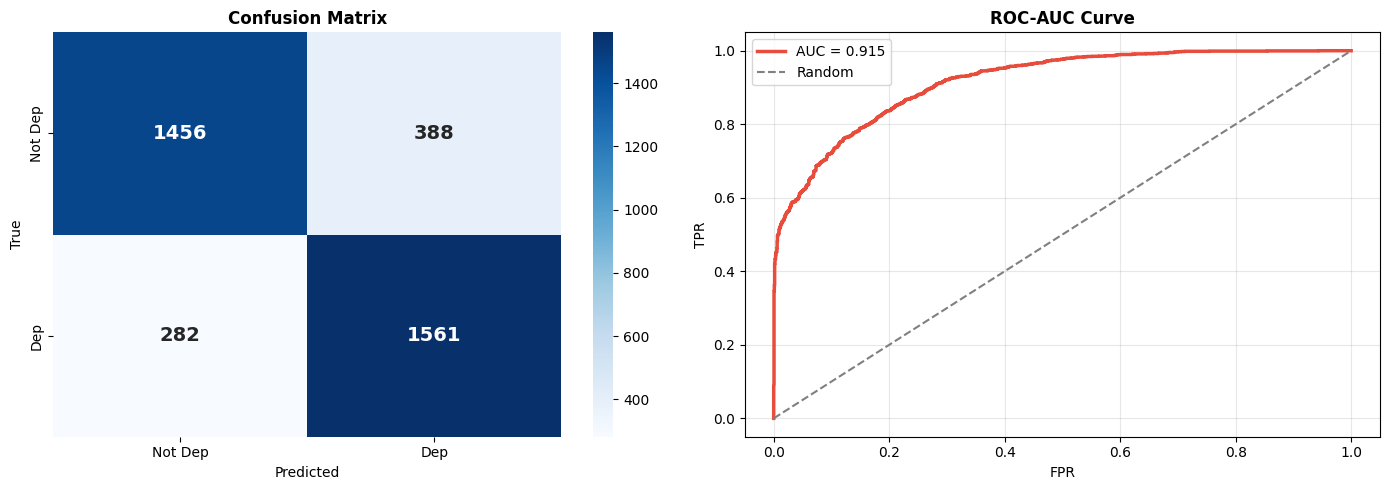

✅ Saved → confusion_roc.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Dep', 'Dep'],
    yticklabels=['Not Dep', 'Dep'],
    ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(test_true, test_probs)
axes[1].plot(fpr, tpr, '#e74c3c', lw=2.5, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → confusion_roc.png")

## STEP 11 — Save Results for NB3

In [13]:
model_results = {
    'test_preds'  : np.array(test_preds),
    'test_true'   : np.array(test_true),
    'test_probs'  : np.array(test_probs),
    'test_attn'   : np.array(test_attn),
    'test_acc'    : float(test_acc),
    'test_f1'     : float(test_f1),
    'test_prec'   : float(test_prec),
    'test_rec'    : float(test_rec),
    'test_auc'    : float(test_auc),
    'test_kappa'  : float(test_kappa),
    'model_state' : best_weights if best_weights is not None else model.state_dict(),
    'model_name'  : MODEL_NAME,
    'history'     : history,
    'n_liwc'      : N_LIWC,
}

RESULTS_PATH = '/kaggle/working/model_results.pkl'
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(model_results, f)

sz = os.path.getsize(RESULTS_PATH) / (1024 * 1024)
print("=" * 55)
print("   ✅ NOTEBOOK 2 COMPLETE!")
print("=" * 55)
print(f"   model_results.pkl  ({sz:.1f} MB)")
print(f"   mentalbert_best.pt")
print(f"   training_curves.png")
print(f"   confusion_roc.png")
print()
print("   📌 Next Steps for NB3:")
print("   1. Output tab → Download model_results.pkl")
print("   2. Also download mentalbert_best.pt")
print("   3. Upload both → NB3 Input section")
print("   4. Run NB3!")
print("=" * 55)

   ✅ NOTEBOOK 2 COMPLETE!
   model_results.pkl  (422.1 MB)
   mentalbert_best.pt
   training_curves.png
   confusion_roc.png

   📌 Next Steps for NB3:
   1. Output tab → Download model_results.pkl
   2. Also download mentalbert_best.pt
   3. Upload both → NB3 Input section
   4. Run NB3!
